In [147]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [171]:
pd.set_option('display.max_rows', None)      # show every row
pd.set_option('display.max_columns', None)   # (optional) show every column

In [148]:
files = glob.glob('shot_pack/shots/*.json')          
dfs   = []
for fp in files:
    with open(fp) as f:
        dfs.append(pd.json_normalize(json.load(f), sep='_'))

shots = pd.concat(dfs, ignore_index=True)

/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_70327/3377725191.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shots = pd.concat(dfs, ignore_index=True)


In [149]:
shots['shot_xg'] = pd.to_numeric(shots.get('shot_xg'), errors='coerce')

if 'shot_isGoal' in shots.columns:
    shots['is_goal'] = shots['shot_isGoal'].astype(int)

elif 'shot_outcome_name' in shots.columns: 
    shots['is_goal'] = (shots['shot_outcome_name'] == 'Goal').astype(int)

elif 'shot.outcome.name' in shots.columns:      
    shots['is_goal'] = (shots['shot.outcome.name'] == 'Goal').astype(int)

else:
    raise KeyError("Could not find a goal indicator column in the data.")

shots['minute_exact'] = shots['minute'] + shots['second'] / 60

In [150]:
def goal_distance(row, goal_x=100, goal_y=50):
    """Euclidean distance (in same coordinate units as location_x/y)."""
    return np.hypot(goal_x - row['location_x'], goal_y - row['location_y'])


shots['shot_distance'] = shots.apply(goal_distance, axis=1)



In [ ]:
shots['isGoal'] = shots['shot_isGoal'].fillna(False)
shots['onTarget'] = shots['shot_onTarget'].fillna(False)
shots['minute_exact'] = shots['minute'] + shots['second']/60

In [177]:
numeric_cols = ['shot_xg', 'shot_distance']  
print("\nGLOBAL DESCRIPTIVE STATS:")
print(shots[numeric_cols].describe().T) 



team_desc = (shots.groupby('team_name')[numeric_cols]
                    .agg(['mean', 'median', 'std', 'min', 'max'])
                    .round(2))

print("\nTEAM-LEVEL DESCRIPTIVE STATS:")
print(team_desc.head(100))



na_counts = shots.isna().sum().sort_values(ascending=False)
# print("\nMISSING VALUES PER COLUMN:")
# print(na_counts[na_counts > 0])           


na_pct = (na_counts / len(shots) * 100).round(2)
na_report = pd.concat([na_counts, na_pct], axis=1, keys=['n_missing', 'pct'])
print("\nNA REPORT:")
print(na_report[na_report['n_missing'] > 0].head(20))  # top 20 missing cols



GLOBAL DESCRIPTIVE STATS:
                count       mean       std       min        25%        50%  \
shot_xg        4582.0   0.122528  0.137155  0.000196   0.030222   0.076420   
shot_distance  4582.0  19.012174  7.613846  2.000000  13.341664  19.104973   

                     75%        max  
shot_xg         0.161175   0.887000  
shot_distance  24.186773  77.077883  

TEAM-LEVEL DESCRIPTIVE STATS:
                     shot_xg                          shot_distance         \
                        mean median   std   min   max          mean median   
team_name                                                                    
AZ                      0.15   0.10  0.15  0.00  0.75         17.78  17.69   
Ajax                    0.09   0.06  0.09  0.00  0.33         23.43  21.21   
Anderlecht              0.11   0.08  0.15  0.01  0.76         20.02  19.24   
Arsenal                 0.17   0.12  0.16  0.00  0.75         16.29  16.40   
Aston Villa             0.14   0.09  0.15  0.00

In [152]:
print("Total shots:", len(shots))
print(shots.groupby('team_name')['id'].count())        # volume
print(shots.groupby('team_name')['isGoal'].sum())      # goals
print(shots.groupby('team_name')['onTarget'].mean())   # accuracy rate

Total shots: 4582
team_name
AZ                       59
Ajax                     24
Anderlecht               31
Arsenal                 142
Aston Villa             107
                       ... 
Tottenham Hotspur        49
Twente                   15
Union Saint-Gilloise     27
Viktoria Plzeň           57
Young Boys               55
Name: id, Length: 63, dtype: int64
team_name
AZ                       6
Ajax                     3
Anderlecht               2
Arsenal                 25
Aston Villa             17
                        ..
Tottenham Hotspur        6
Twente                   2
Union Saint-Gilloise     1
Viktoria Plzeň           7
Young Boys               3
Name: isGoal, Length: 63, dtype: int64
team_name
AZ                      0.355932
Ajax                    0.541667
Anderlecht              0.258065
Arsenal                 0.471831
Aston Villa             0.439252
                          ...   
Tottenham Hotspur       0.346939
Twente                  0.400000
Union Sai

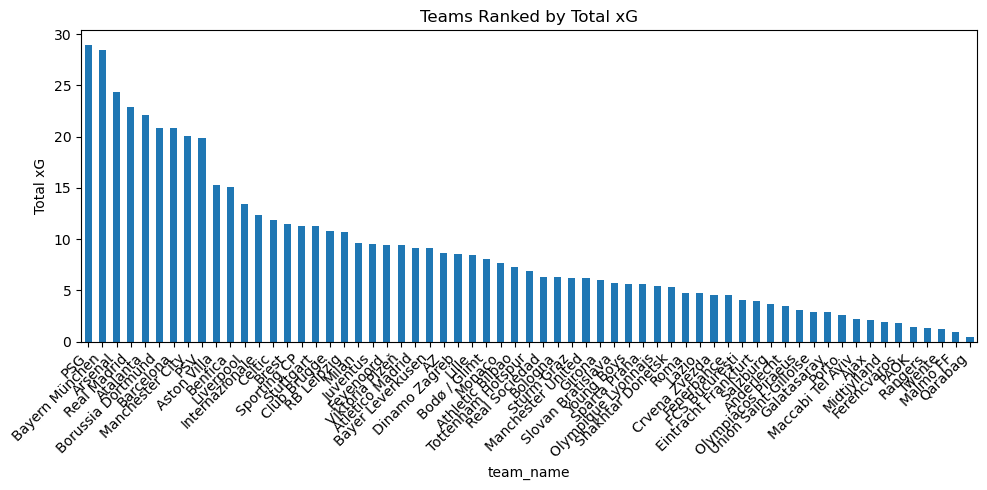

In [153]:
team_totals = (shots.groupby('team_name')['shot_xg']
                      .sum()
                      .sort_values(ascending=False))

plt.figure(figsize=(10, 5))
team_totals.plot(kind='bar')    # bar chart == ranked histogram
plt.ylabel('Total xG')
plt.title('Teams Ranked by Total xG')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [154]:
shots['shot_xg']       = pd.to_numeric(shots.get('shot_xg'), errors='coerce')
shots['minute_exact']  = shots['minute'] + shots['second'] / 60


team_top10 = (shots.groupby('team_name')
                     .agg(total_xg=('shot_xg', 'sum'),
                          goals=('is_goal', 'sum'))
                     .sort_values('total_xg', ascending=False)
                     .head(10)
                     .reset_index())

player_top10 = (shots.groupby('player_name')
                      .agg(total_xg=('shot_xg', 'sum'),
                           goals=('shot_isGoal', 'sum'),
                           shots=('id', 'count'))
                      .sort_values('total_xg', ascending=False)
                      .head(10)
                      .reset_index())

In [155]:
print("\nTop-10 teams by total xG")
print(team_top10.to_string(index=False))


Top-10 teams by total xG
        team_name  total_xg  goals
              PSG 28.914568     31
   Bayern München 28.437828     21
          Arsenal 24.359140     25
      Real Madrid 22.932526     28
         Atalanta 22.063755     21
Borussia Dortmund 20.870028     21
        Barcelona 20.820661     28
  Manchester City 20.023405     17
              PSV 19.896424     19
      Aston Villa 15.307403     17


In [156]:
team_summary = (shots.groupby('team_name')
                      .agg(shots=('id', 'count'),
                           goals=('is_goal', 'sum'),
                           total_xg=('shot_xg', 'sum'),
                           avg_xg=('shot_xg', 'mean'),
                           med_xg=('shot_xg', 'median'),
                           acc_rate=('onTarget', 'mean'),
                           conv_rate=('is_goal', 'mean'),
                           avg_dist=('shot_distance', 'mean'))
                      .round(2)
                      .sort_values('total_xg', ascending=False)
                      .head(10))

print("\nDetailed Top-10 team summary")
print(team_summary)


Detailed Top-10 team summary
                   shots  goals  total_xg  avg_xg  med_xg  acc_rate  \
team_name                                                             
PSG                  245     31     28.91    0.12    0.07      0.40   
Bayern München       226     21     28.44    0.13    0.08      0.38   
Arsenal              142     25     24.36    0.17    0.12      0.47   
Real Madrid          165     28     22.93    0.14    0.09      0.44   
Atalanta             156     21     22.06    0.14    0.10      0.37   
Borussia Dortmund    160     21     20.87    0.13    0.08      0.44   
Barcelona            144     28     20.82    0.14    0.09      0.47   
Manchester City      155     17     20.02    0.13    0.09      0.41   
PSV                  183     19     19.90    0.11    0.07      0.38   
Aston Villa          107     17     15.31    0.14    0.09      0.44   

                   conv_rate  avg_dist  
team_name                               
PSG                     0.13     19

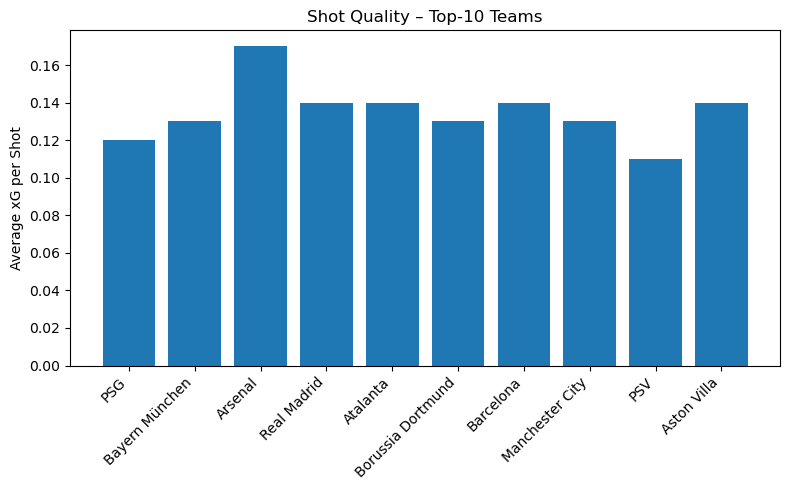

In [157]:
plt.figure(figsize=(8, 5))
plt.bar(team_summary.index, team_summary['avg_xg'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average xG per Shot')
plt.title('Shot Quality – Top-10 Teams')
plt.tight_layout()
plt.show()

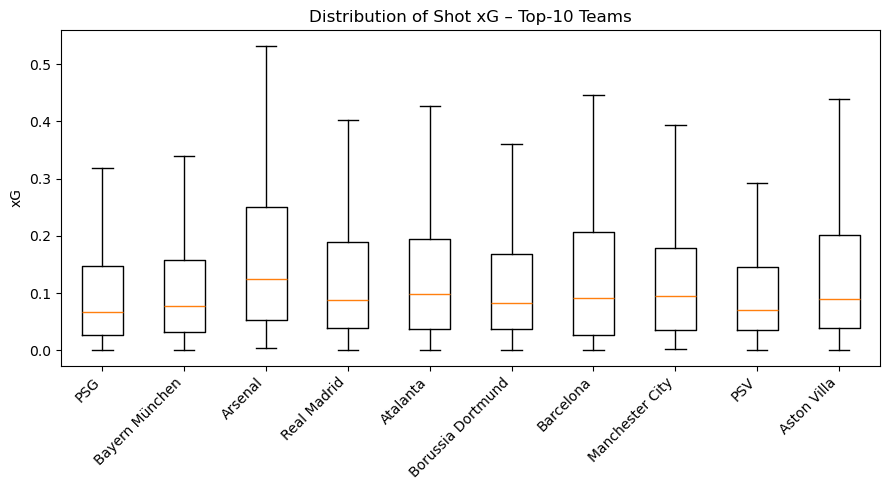

In [158]:
plt.figure(figsize=(9, 5))
box_data = [shots.loc[shots.team_name == t, 'shot_xg'] for t in team_summary.index]
plt.boxplot(box_data, labels=team_summary.index, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.ylabel('xG')
plt.title('Distribution of Shot xG – Top-10 Teams')
plt.tight_layout()
plt.show()

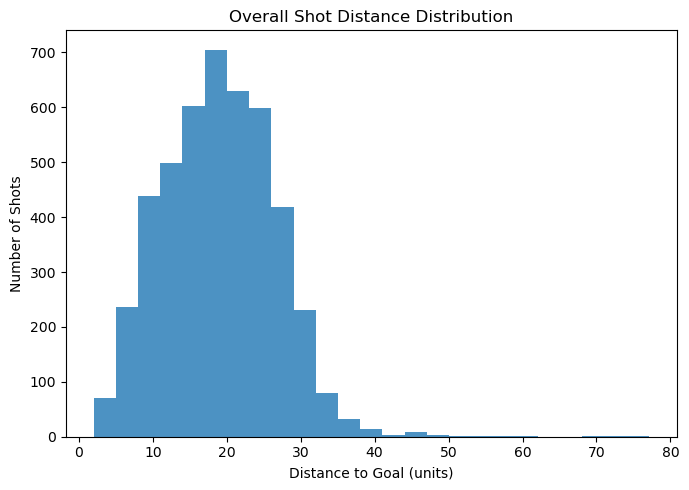

In [159]:
plt.figure(figsize=(7, 5))
plt.hist(shots['shot_distance'], bins=25, alpha=.8)
plt.xlabel('Distance to Goal (units)')
plt.ylabel('Number of Shots')
plt.title('Overall Shot Distance Distribution')
plt.tight_layout()
plt.show()

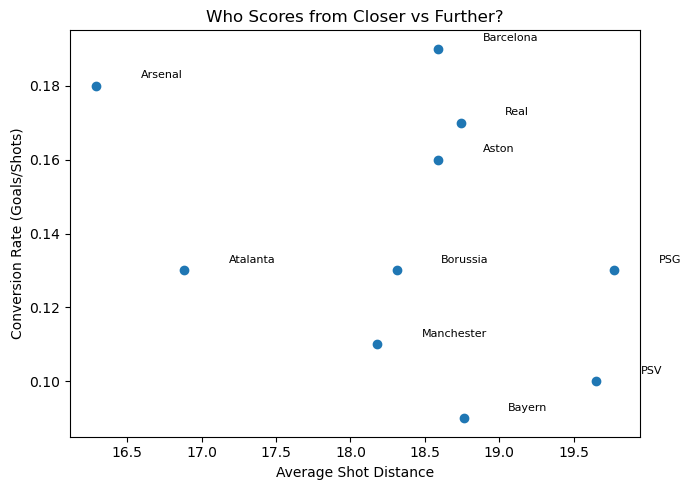

In [160]:
plt.figure(figsize=(7, 5))
plt.scatter(team_summary['avg_dist'], team_summary['conv_rate'])
for team, row in team_summary.iterrows():
    plt.text(row['avg_dist'] + 0.3,
             row['conv_rate'] + 0.002,
             team.split(' ')[0],
             fontsize=8)
plt.xlabel('Average Shot Distance')
plt.ylabel('Conversion Rate (Goals/Shots)')
plt.title('Who Scores from Closer vs Further?')
plt.tight_layout()
plt.show()

In [161]:
print("\nTop-10 players by total xG")
print(player_top10.to_string(index=False))


Top-10 players by total xG
    player_name  total_xg  goals  shots
        H. Kane  7.801916      7     42
      K. Mbappé  6.768256      7     41
    S. Guirassy  6.109559      7     30
     E. Haaland  6.092070      6     30
     B. Barcola  5.561400      3     26
     O. Dembélé  5.320297      8     49
       Raphinha  4.798541     10     35
     L. de Jong  4.419090      2     23
Vinícius Júnior  4.401799      7     31
    V. Pavlidis  4.382569      5     18


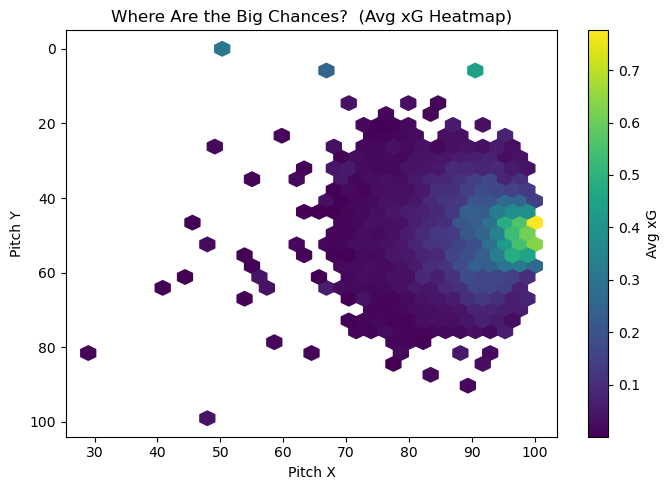

In [162]:
plt.figure(figsize=(7, 5))

valid = shots[['location_x', 'location_y', 'shot_xg']].dropna()

hb = plt.hexbin(valid['location_x'],
                valid['location_y'],
                C=valid['shot_xg'],
                reduce_C_function=np.mean, 
                gridsize=30,
                cmap='viridis')

plt.colorbar(hb, label='Avg xG')
plt.gca().invert_yaxis()
plt.xlabel('Pitch X')
plt.ylabel('Pitch Y')
plt.title('Where Are the Big Chances?  (Avg xG Heatmap)')
plt.tight_layout()
plt.show()


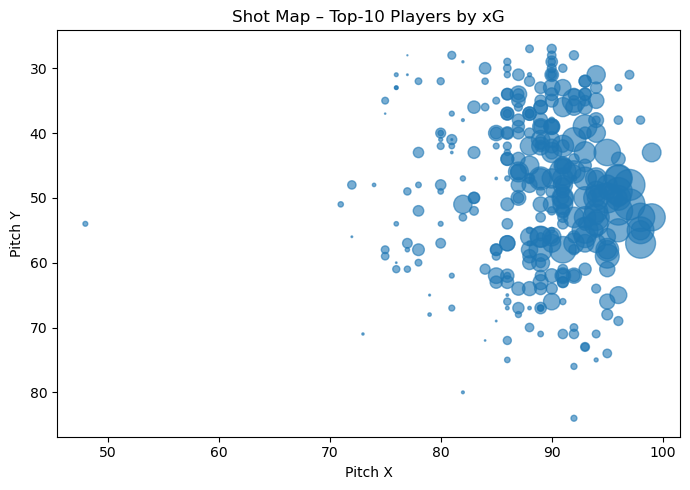

In [163]:
shots_p10 = shots[shots['player_name'].isin(player_top10['player_name'])]

plt.figure(figsize=(7, 5))
plt.scatter(
    shots_p10['location_x'],
    shots_p10['location_y'],
    s=shots_p10['shot_xg'] * 600,        # bubble ∝ xG
    alpha=.6
)
plt.gca().invert_yaxis()
plt.title('Shot Map – Top-10 Players by xG')
plt.xlabel('Pitch X')
plt.ylabel('Pitch Y')
plt.tight_layout()
plt.show()

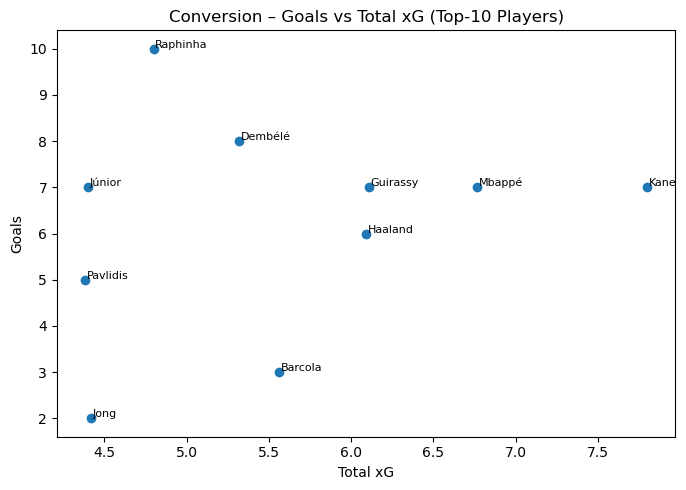

In [164]:
plt.figure(figsize=(7, 5))
plt.scatter(player_top10['total_xg'], player_top10['goals'])
for _, row in player_top10.iterrows():
    last = row['player_name'].split(' ')[-1]
    plt.text(row['total_xg'] + 0.01, row['goals'] + 0.02, last, fontsize=8)
plt.title('Conversion – Goals vs Total xG (Top-10 Players)')
plt.xlabel('Total xG')
plt.ylabel('Goals')
plt.tight_layout()
plt.show()

In [165]:
possible = [c for c in shots.columns
            if c.lower() in ['match_id', 'matchid', 'fixture_id', 'game_id']]
match_col = possible[0]          # pick the first hit



/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_70327/136262247.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))


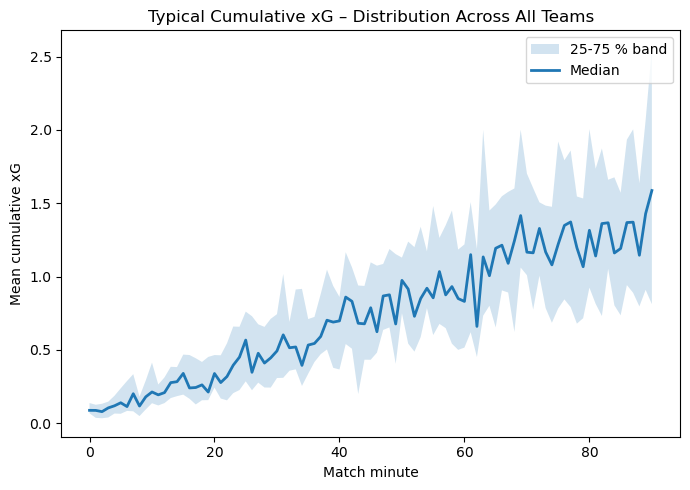

In [166]:
# create integer minute once
shots['minute_int'] = shots['minute_exact'].round().astype(int)

# per-match cumulative xG
match_cum = (shots.sort_values(['team_name', match_col, 'minute_int'])
                   .groupby(['team_name', match_col])
                   .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))
                   .reset_index(drop=True))

# average across matches
mean_curve = (match_cum.groupby(['team_name', 'minute_int'])['cumu']
                       .mean()
                       .reset_index())

pivot = (mean_curve.pivot(index='minute_int',
                          columns='team_name',
                          values='cumu')
                    .reindex(range(0, 91)))      # ensure full minute index

median = pivot.median(axis=1)
p25    = pivot.quantile(0.25, axis=1)
p75    = pivot.quantile(0.75, axis=1)

plt.figure(figsize=(7, 5))
plt.fill_between(pivot.index, p25, p75, alpha=0.2, label='25-75 % band')
plt.plot(pivot.index, median, linewidth=2, label='Median')

plt.xlabel('Match minute')
plt.ylabel('Mean cumulative xG')
plt.title('Typical Cumulative xG – Distribution Across All Teams')
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_70327/2218167672.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))


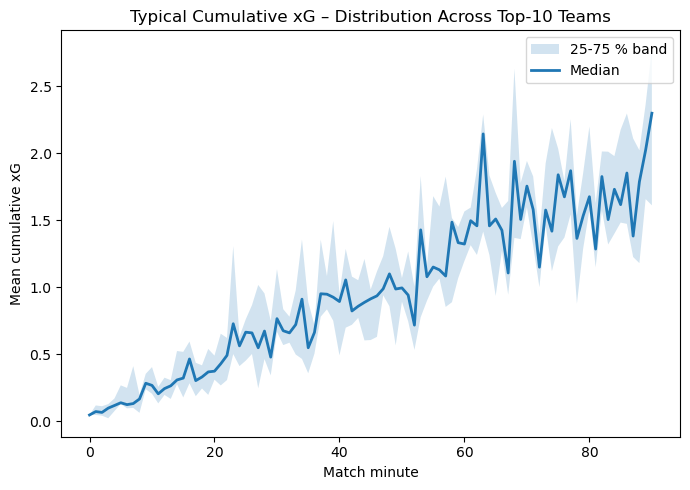

In [167]:
top10_names = team_top10['team_name'].tolist()       
shots_t10   = shots[shots['team_name'].isin(top10_names)].copy()

shots_t10['minute_int'] = shots_t10['minute_exact'].round().astype(int)

match_cum = (shots_t10.sort_values(['team_name', match_col, 'minute_int'])
                    .groupby(['team_name', match_col])
                    .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))
                    .reset_index(drop=True))

mean_curve = (match_cum.groupby(['team_name', 'minute_int'])['cumu']
                       .mean()
                       .reset_index())


pivot  = (mean_curve.pivot(index='minute_int',
                           columns='team_name',
                           values='cumu')
                     .reindex(range(0, 91)))

median = pivot.median(axis=1)
p25    = pivot.quantile(0.25, axis=1)
p75    = pivot.quantile(0.75, axis=1)

plt.figure(figsize=(7, 5))
plt.fill_between(pivot.index, p25, p75, alpha=0.2, label='25-75 % band')
plt.plot(pivot.index, median, linewidth=2, label='Median')

plt.xlabel('Match minute')
plt.ylabel('Mean cumulative xG')
plt.title('Typical Cumulative xG – Distribution Across Top-10 Teams')
plt.legend()
plt.tight_layout()
plt.show()


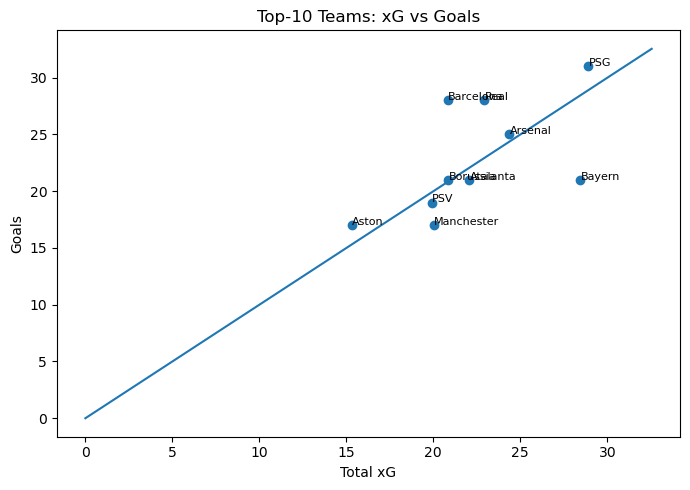

In [168]:
plt.figure(figsize=(7, 5))
plt.scatter(team_top10['total_xg'], team_top10['goals'])
max_val = max(team_top10['total_xg'].max(), team_top10['goals'].max()) * 1.05
plt.plot([0, max_val], [0, max_val])        # 45° reference line
for _, row in team_top10.iterrows():
    plt.text(row['total_xg'] + 0.03,
             row['goals']   + 0.03,
             row['team_name'].split(' ')[0],
             fontsize=8)
plt.xlabel('Total xG')
plt.ylabel('Goals')
plt.title('Top-10 Teams: xG vs Goals')
plt.tight_layout()
plt.show()